Sel 1 — Mount Google Drive & Install Library

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-learn opencv-python lime tqdm -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Sel 2 — Import Library

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import joblib

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

from lime import lime_image
from skimage.segmentation import mark_boundaries

Sel 3 — Konfigurasi Path & Parameter

In [ ]:
BASE_DIR   = Path("/content/drive/MyDrive/Pothole_Classification_Project")
TRAIN_DIR  = BASE_DIR / "dataset/2_processed/train"
TEST_DIR   = BASE_DIR / "dataset/2_processed/test"
MODEL_DIR  = BASE_DIR / "saved_models"
OUTPUT_DIR = BASE_DIR / "outputs"

CLASSES    = ["berlubang", "mulus"]
IMG_SIZE   = (64, 64)
FLAT_SIZE  = IMG_SIZE[0] * IMG_SIZE[1] * 3

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Konfigurasi siap.")
print(f"   Panjang vektor input : {FLAT_SIZE}")

✅ Konfigurasi siap.
   Panjang vektor input : 12288


Sel 4 — Fungsi Load & Flatten

In [ ]:
def load_and_flatten(img_path, size=IMG_SIZE):
    """
    Baca gambar → resize → normalisasi [0,1] → flatten jadi 1D vektor.
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, size, interpolation=cv2.INTER_AREA)
    img_norm    = img_resized.astype(np.float32) / 255.0
    return img_norm.flatten()

Sel 5 — Load Train Set

In [ ]:
print("⚙️  Memuat Train Set...\n")

X_train, y_train = [], []

for label_idx, cls in enumerate(CLASSES):
    paths = list((TRAIN_DIR / cls).glob("*.jpg"))
    for path in tqdm(paths, desc=f"[{cls}]"):
        feat = load_and_flatten(path)
        if feat is not None:
            X_train.append(feat)
            y_train.append(label_idx)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"\n✅ Train set siap.")
print(f"   Jumlah sampel : {X_train.shape[0]}")
print(f"   Panjang vektor: {X_train.shape[1]}")

⚙️  Memuat Train Set...



[mulus]: 100%|██████████| 1540/1540 [00:31<00:00, 49.24it/s] 



✅ Train set siap.
   Jumlah sampel : 3080
   Panjang vektor: 12288


Sel 6 — Load Test Set

In [ ]:
print("⚙️  Memuat Test Set...\n")

X_test, y_test  = [], []
test_images_raw = []

for label_idx, cls in enumerate(CLASSES):
    paths = list((TEST_DIR / cls).glob("*.jpg"))
    for path in tqdm(paths, desc=f"[{cls}]"):
        img = cv2.imread(str(path))
        if img is None:
            continue
        img_rgb     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (224, 224))
        test_images_raw.append(img_resized)

        feat = load_and_flatten(path)
        if feat is not None:
            X_test.append(feat)
            y_test.append(label_idx)

X_test          = np.array(X_test)
y_test          = np.array(y_test)
test_images_raw = np.array(test_images_raw)

print(f"\n✅ Test set siap.")
print(f"   Jumlah sampel : {X_test.shape[0]}")

⚙️  Memuat Test Set...



[mulus]: 100%|██████████| 35/35 [00:00<00:00, 38.78it/s]


✅ Test set siap.
   Jumlah sampel : 70


Sel 7 — Normalisasi Fitur

In [ ]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("✅ Fitur dinormalisasi dengan StandardScaler.")

✅ Fitur dinormalisasi dengan StandardScaler.


Sel 8 — Hyperparameter Tuning + Training MLP

In [ ]:
# print("🔍 Memulai Hyperparameter Tuning (GridSearchCV)...\n")

# param_grid = {
#     "hidden_layer_sizes": [(128, 64), (256, 128)],
#     "activation"        : ["relu"],
#     "alpha"             : [1e-4, 1e-3],   # L2 regularization
#     "learning_rate_init": [1e-3, 1e-4],
# }

# mlp = MLPClassifier(
#     max_iter     = 300,
#     random_state = 42,
#     early_stopping = True,      # Otomatis berhenti jika tidak ada peningkatan
#     validation_fraction = 0.1,
#     n_iter_no_change = 10,
# )

# grid_search = GridSearchCV(
#     estimator  = mlp,
#     param_grid = param_grid,
#     cv         = 5,
#     scoring    = "accuracy",
#     n_jobs     = -1,
#     verbose    = 2
# )

# grid_search.fit(X_train, y_train)

# print("\n✅ Tuning selesai!")
# print(f"   Best Params   : {grid_search.best_params_}")
# print(f"   Best CV Score : {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

# mlp_model = grid_search.best_estimator_

Sel 9 — Training MLP (Parameter Terbaik)

In [ ]:
# Sel ini dibuat untuk mempercepat proses training, karena sebelumnya sudah dilakukan hyperparameter tuning
# Jadi tinggal menuliskan hasil parameter terbaik dari hyperparameter sebelumnya saja
print("🏋️  Melatih MLP dengan parameter terbaik...\n")

mlp_model = MLPClassifier(
    hidden_layer_sizes  = (256, 128),
    activation          = "relu",
    alpha               = 1e-3,
    learning_rate_init  = 1e-3,
    max_iter            = 100,
    random_state        = 42,
    early_stopping      = True,
    validation_fraction = 0.1,
    n_iter_no_change    = 10,
)

mlp_model.fit(X_train, y_train)

print("✅ Training selesai!")

🏋️  Melatih MLP dengan parameter terbaik...

✅ Training selesai!


Sel 10 — Evaluasi Model

In [ ]:
y_pred = mlp_model.predict(X_test)

acc  = accuracy_score (y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec  = recall_score   (y_test, y_pred, average="weighted")
f1   = f1_score       (y_test, y_pred, average="weighted")

print("=" * 45)
print("        HASIL EVALUASI — MLP Classifier")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("=" * 45)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASSES))

        HASIL EVALUASI — MLP Classifier
  Accuracy  : 0.9429  (94.29%)
  Precision : 0.9443
  Recall    : 0.9429
  F1-Score  : 0.9428

Classification Report:

              precision    recall  f1-score   support

   berlubang       0.97      0.91      0.94        35
       mulus       0.92      0.97      0.94        35

    accuracy                           0.94        70
   macro avg       0.94      0.94      0.94        70
weighted avg       0.94      0.94      0.94        70



Sel 11 — Confusion Matrix

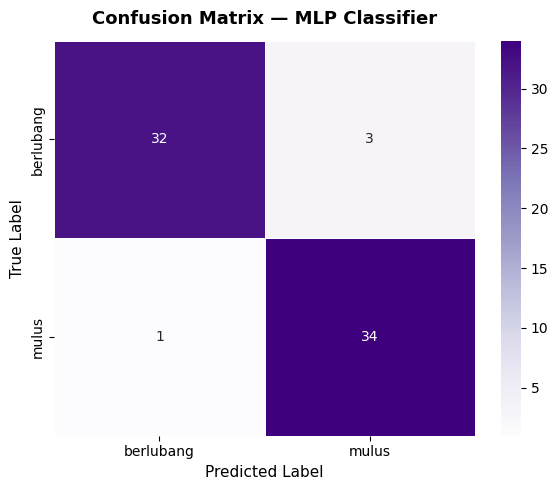

✅ Confusion matrix disimpan ke outputs/


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix — MLP Classifier", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cm_mlp.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix disimpan ke outputs/")

Sel 12 — Plot Training Loss Curve

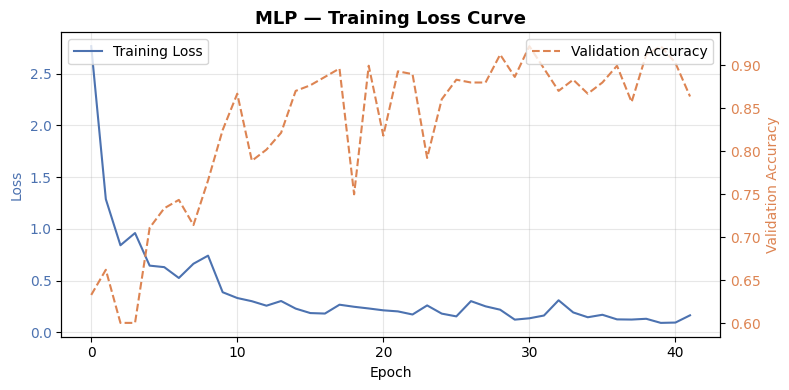

✅ Loss curve disimpan ke outputs/


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_model.loss_curve_, color="#4C72B0", label="Training Loss")

if mlp_model.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp_model.validation_scores_, color="#DD8452",
             linestyle="--", label="Validation Accuracy")
    ax2.set_ylabel("Validation Accuracy", color="#DD8452")
    ax2.tick_params(axis="y", labelcolor="#DD8452")
    ax2.legend(loc="upper right")

ax.set_title("MLP — Training Loss Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss", color="#4C72B0")
ax.tick_params(axis="y", labelcolor="#4C72B0")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mlp_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Loss curve disimpan ke outputs/")

Sel 13 — Cross Validation Score

🔍 Menghitung Cross Validation Score...

  CV Scores per fold : ['0.8669', '0.9042', '0.8912', '0.8734', '0.9091']
  Mean CV Accuracy   : 0.8890 (88.90%)
  Std CV Accuracy    : 0.0166
  Test Accuracy      : 0.9429 (94.29%)
  Selisih CV vs Test : 0.0539


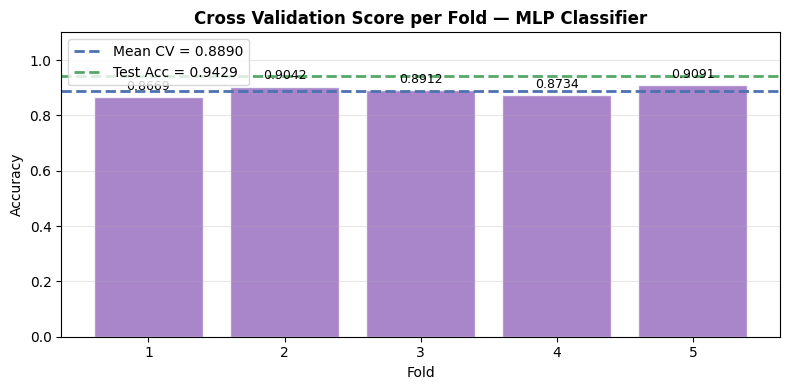

✅ CV scores disimpan ke outputs/


In [ ]:
print("🔍 Menghitung Cross Validation Score...\n")

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp",    MLPClassifier(
        hidden_layer_sizes  = (256, 128),
        activation          = "relu",
        alpha               = 1e-3,
        learning_rate_init  = 1e-3,
        max_iter            = 100,
        random_state        = 42,
        early_stopping      = True,
        validation_fraction = 0.1,
        n_iter_no_change    = 10,
    ))
])

X_train_raw, y_train_raw = [], []
for label_idx, cls in enumerate(CLASSES):
    paths = list((TRAIN_DIR / cls).glob("*.jpg"))
    for path in paths:
        feat = load_and_flatten(path)
        if feat is not None:
            X_train_raw.append(feat)
            y_train_raw.append(label_idx)

X_train_raw = np.array(X_train_raw)
y_train_raw = np.array(y_train_raw)

cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_raw, y_train_raw,
                             cv=cv, scoring="accuracy", n_jobs=-1)

print(f"  CV Scores per fold : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean CV Accuracy   : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"  Std CV Accuracy    : {cv_scores.std():.4f}")
print(f"  Test Accuracy      : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Selisih CV vs Test : {abs(cv_scores.mean() - acc):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(1, 6), cv_scores, color="#9467bd", alpha=0.8, edgecolor="white")
ax.axhline(cv_scores.mean(), color="#4C72B0", linestyle="--",
           linewidth=2, label=f"Mean CV = {cv_scores.mean():.4f}")
ax.axhline(acc, color="#55A868", linestyle="--",
           linewidth=2, label=f"Test Acc = {acc:.4f}")
ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
ax.set_title("Cross Validation Score per Fold — MLP Classifier",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cv_scores_mlp.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ CV scores disimpan ke outputs/")

Sel 14 — Diagnosis Otomatis

In [ ]:
print("\n" + "=" * 50)
print("      DIAGNOSIS MODEL — MLP Classifier")
print("=" * 50)

cv_test_gap = abs(cv_scores.mean() - acc)

print(f"\n  Mean CV Accuracy   : {cv_scores.mean():.4f}")
print(f"  Test Accuracy      : {acc:.4f}")
print(f"  Std CV             : {cv_scores.std():.4f}")
print(f"  Gap CV vs Test     : {cv_test_gap:.4f}")

print("\n  📋 Kesimpulan:")

if cv_scores.mean() < 0.7 and acc < 0.7:
    print("  ⚠️  UNDERFITTING — Akurasi CV dan Test sama-sama rendah.")
    print("      Saran: tambah hidden layer atau neuron.")

elif acc - cv_scores.mean() > 0.1:
    print("  ⚠️  OVERFITTING — Test accuracy jauh lebih tinggi dari CV.")
    print("      Saran: naikkan alpha (regularisasi L2) atau tambah dropout.")

elif cv_scores.mean() - acc > 0.1:
    print("  ⚠️  DISTRIBUSI TIDAK KONSISTEN — CV jauh lebih tinggi dari Test.")
    print("      Kemungkinan distribusi train dan test tidak seragam.")

elif cv_scores.std() > 0.05:
    print("  ⚠️  VARIANCE TINGGI — Performa tidak stabil antar fold.")
    print("      Model sensitif terhadap pembagian data.")

else:
    print("  ✅ MODEL SEHAT — Tidak terdeteksi overfitting maupun underfitting.")
    print(f"     Performa stabil dengan std CV = {cv_scores.std():.4f}")
    print(f"     Gap CV vs Test = {cv_test_gap:.4f} (dalam batas wajar)")

print("=" * 50)


      DIAGNOSIS MODEL — MLP Classifier

  Mean CV Accuracy   : 0.8890
  Test Accuracy      : 0.9429
  Std CV             : 0.0166
  Gap CV vs Test     : 0.0539

  📋 Kesimpulan:
  ✅ MODEL SEHAT — Tidak terdeteksi overfitting maupun underfitting.
     Performa stabil dengan std CV = 0.0166
     Gap CV vs Test = 0.0539 (dalam batas wajar)


Sel 15 — LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

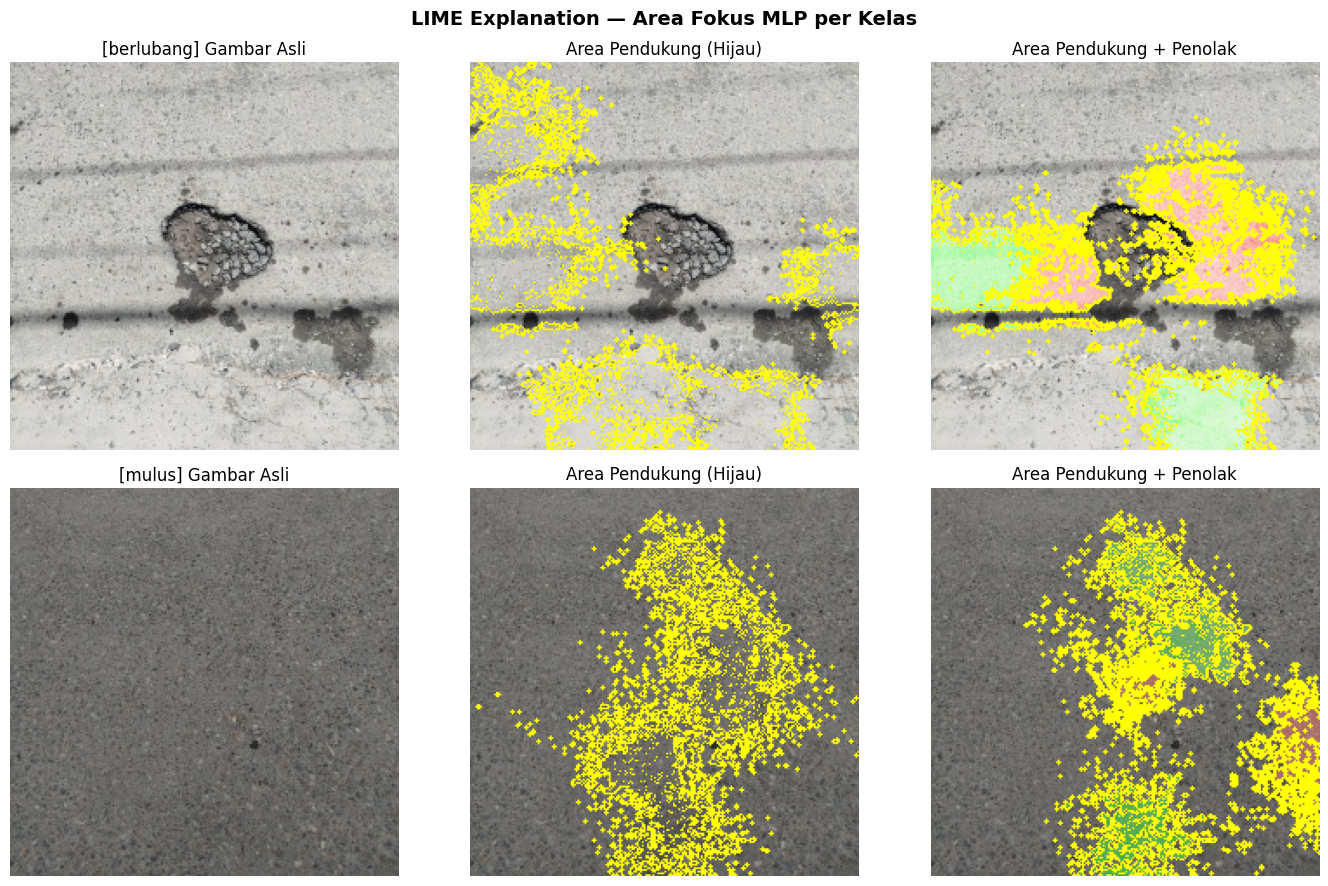

✅ Visualisasi LIME disimpan ke outputs/


In [ ]:
def predict_fn_mlp(images):
    batch = []
    for img in images:
        img_resized = cv2.resize(img.astype(np.uint8), IMG_SIZE)
        img_norm    = img_resized.astype(np.float32) / 255.0
        batch.append(img_norm.flatten())

    batch_scaled = scaler.transform(np.array(batch))
    return mlp_model.predict_proba(batch_scaled)

explainer = lime_image.LimeImageExplainer()

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("LIME Explanation — Area Fokus MLP per Kelas",
             fontsize=14, fontweight="bold")

sample_indices = {
    "berlubang": np.where(y_test == 0)[0][0],
    "mulus"    : np.where(y_test == 1)[0][0]
}

for row, (cls, idx) in enumerate(sample_indices.items()):
    img_display = test_images_raw[idx]

    explanation = explainer.explain_instance(
        img_display.astype(np.double),
        predict_fn_mlp,
        top_labels  = 2,
        hide_color  = 0,
        num_samples = 1000
    )

    label_idx = 0 if cls == "berlubang" else 1

    axes[row, 0].imshow(img_display)
    axes[row, 0].set_title(f"[{cls}] Gambar Asli")
    axes[row, 0].axis("off")

    temp_pos, mask_pos = explanation.get_image_and_mask(
        label_idx, positive_only=True, num_features=5, hide_rest=False
    )
    axes[row, 1].imshow(mark_boundaries(temp_pos.astype(np.uint8), mask_pos))
    axes[row, 1].set_title("Area Pendukung (Hijau)")
    axes[row, 1].axis("off")

    temp_neg, mask_neg = explanation.get_image_and_mask(
        label_idx, positive_only=False, num_features=5, hide_rest=False
    )
    axes[row, 2].imshow(mark_boundaries(temp_neg.astype(np.uint8), mask_neg))
    axes[row, 2].set_title("Area Pendukung + Penolak")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lime_mlp.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisasi LIME disimpan ke outputs/")

Sel 16 — Simpan Model

In [ ]:
joblib.dump(mlp_model, MODEL_DIR / "mlp_model.pkl")
joblib.dump(scaler,    MODEL_DIR / "scaler_mlp.pkl")

print("✅ Model tersimpan:")
print(f"   → {MODEL_DIR / 'mlp_model.pkl'}")
print(f"   → {MODEL_DIR / 'scaler_mlp.pkl'}")

✅ Model tersimpan:
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/mlp_model.pkl
   → /content/drive/MyDrive/Pothole_Classification_Project/saved_models/scaler_mlp.pkl
